In [200]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [201]:
data= pd.read_excel("/Users/tam_pr/Desktop/stats/stats/database/dataframe.xlsx")

In [202]:
data.head()

,Sale price,Age,Mileage,Condition,Unnamed: 4,Unnamed: 5
0,(pesos),(years),(miles),Promedio,Excellent,One owner
1,60000,9,112,1,0,1
2,54000,9,159,0,0,1
3,59900,8,192,0,0,1
4,110000,7,90,1,0,0


In [203]:
data.describe()

#data.dropna(axis=0)

data.head()
data.columns

Index(['Sale price', 'Age', 'Mileage', 'Condition', 'Unnamed: 4',
       'Unnamed: 5'],
      dtype='str')

In [204]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sale price  32 non-null     object
 1   Age         32 non-null     object
 2   Mileage     32 non-null     object
 3   Condition   32 non-null     object
 4   Unnamed: 4  32 non-null     object
 5   Unnamed: 5  32 non-null     object
dtypes: object(6)
memory usage: 1.6+ KB


Calculate the correlation coeficients of each out value w predictor value. 

then do the mathematical shit to "prove" it
do the outliers treatment 


In [205]:
y = data["Sale price"]
y.dtypes

y = y.iloc[1:]

In [206]:
y = y.astype(int) #out variable 

age = data["Age"]
age = age.iloc[1:]
age = age.astype(int)

mileage = data["Mileage"]
mileage = mileage.iloc[1:]
mileage = mileage.astype(int)


## Age vs Sale Price

In [207]:
age_saleprice = pd.DataFrame({
    "Age (x)": age,
    "Sale price (y)": y
})
age_saleprice

,Age (x),Sale price (y)
1,9,60000
2,9,54000
3,8,59900
4,7,110000
5,7,79760
6,7,78000
7,7,56000
8,6,136000
9,6,125900
10,6,74000


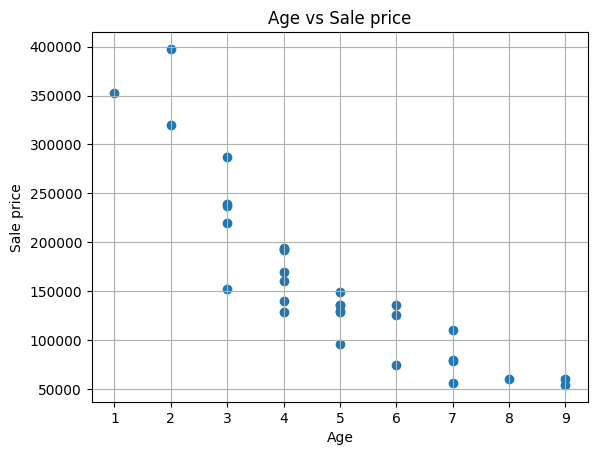

In [208]:
plt.scatter(age,y)

plt.xlabel("Age")
plt.ylabel("Sale price")    
plt.title("Age vs Sale price")

plt.grid()
plt.show()

What this graph is showing us is a relation between the age of a vehicle and its selling price, as we can see, we could say that the older a car is the lower its selling price. 

## Pearson coefficient 

## Linear regression 

In [209]:
def getLinearRegression(x,y): 
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_xmean = []

    for i in x: 
        x_xmean.append(i-x_mean)

    y_ymean = []
    for i in y:
        y_ymean.append(i-y_mean)

    n = len(x)

    sxy_elements = []
    for i in range(n): 
        sxy_elements.append(x_xmean[i]*y_ymean[i])

    sxy = sum(sxy_elements)

    sxx_elements = []
    for i in range(n):
        sxx_elements.append(x_xmean[i]**2)

    sxx = sum(sxx_elements)

    syy_elements = []
    for i in range(n):
        syy_elements.append(y_ymean[i]**2)

    syy = sum(syy_elements)

    sqrt_sxx = (sxx)**0.5
    sqrt_syy = (syy)**0.5

    r = sxy/(sqrt_sxx*sqrt_syy)


    b1 = sxy/sxx
    b0 = y_mean - (b1*x_mean)

    return b1, b0, r 

b1_age,b0_age,r_age= getLinearRegression(age,y)

print ("Slope:", b1_age)
print ("Intercept", b0_age)
print ("Pearson coefficient: ", r_age)
    

Slope: -38184.369296833065
Intercept 345832.10950080515
Pearson coefficient:  -0.8724384262540563


In [210]:
#Checking w built in functions

from sklearn.linear_model import LinearRegression

model = LinearRegression()

X_age = age.values.reshape(-1,1)
model.fit(X_age, y)

print("Slope: ", model.coef_) 
print("Intercept: ", model.intercept_)   
print("Pearson coeficient: ", age.corr(y))

Slope:  [-38184.36929683]
Intercept:  345832.10950080515
Pearson coeficient:  -0.8724384262540567


In [211]:
def residualFunctions(x, y, b1, b0):

    y_pred = b0 + b1*x

    SSE = sum((y - y_pred)**2)

    SST = sum((y - np.mean(y))**2)

    R_squared = 1 - (SSE/SST)

    return R_squared

In [212]:
R_squared_age= residualFunctions(age,y,b1_age,b0_age)
print("R-squared: ", R_squared_age)


R-squared:  0.7611488076046544


In [213]:
model = LinearRegression()
model.fit(X_age, y)

model.score(X_age,y)

0.7611488076046545

## Regression line plot 

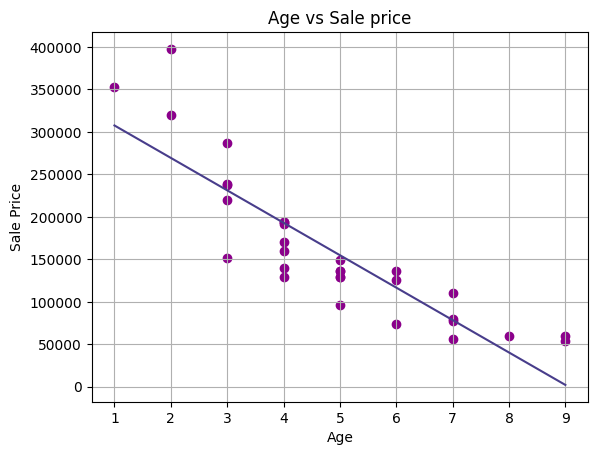

In [214]:
plt.scatter(age, y, color="darkmagenta")

y_pred = b0_age + b1_age*age

plt.plot(age, y_pred,color="darkslateblue")

plt.xlabel("Age")
plt.ylabel("Sale Price")
plt.title("Age vs Sale price")


plt.grid()

plt.show()

## Intepreting Pearson coefficient 

After calculating and comparing with the graph we can confidently say that theres a negative linear relation between the age of the vehicle and the sale price of it. <br>

## Mileage vs Sale Price

In [215]:
mileage_saleprice = pd.DataFrame({
    "Mileage(x)": mileage,
    "Sale price (y)": y
})
mileage_saleprice

,Mileage(x),Sale price (y)
1,112,60000
2,159,54000
3,192,59900
4,90,110000
5,80,79760
6,133,78000
7,170,56000
8,112,136000
9,106,125900
10,96,74000


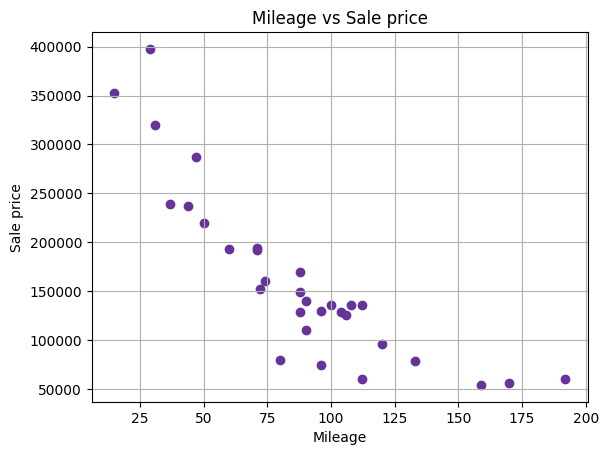

In [216]:
plt.scatter(mileage,y, color="rebeccapurple")

plt.xlabel("Mileage")
plt.ylabel("Sale price")    
plt.title("Mileage vs Sale price")

plt.grid()
plt.show()

In [217]:
b1_mileage,b0_mileage,r_mileage= getLinearRegression(mileage,y)

print ("Slope:", b1_mileage)
print ("Intercept", b0_mileage)
print ("Pearson coefficient: ", r_mileage)

Slope: -1844.7995186003025
Intercept 323708.9382043428
Pearson coefficient:  -0.8565929493827974


In [218]:
model = LinearRegression()

X_mileage = mileage.values.reshape(-1,1)
model.fit(X_mileage, y)

print("Slope: ", model.coef_) 
print("Intercept: ", model.intercept_)   
print("Pearson coeficient: ", mileage.corr(y))

Slope:  [-1844.7995186]
Intercept:  323708.93820434273
Pearson coeficient:  -0.8565929493827973


In [219]:
R_squared_mileage= residualFunctions(mileage,y,b1_mileage,b0_mileage)
print("R-squared: ", R_squared_mileage)


R-squared:  0.7337514809323193


In [220]:
model = LinearRegression()
model.fit(X_mileage, y)
model.score(X_mileage,y)

0.7337514809323195

## Regression line plot 

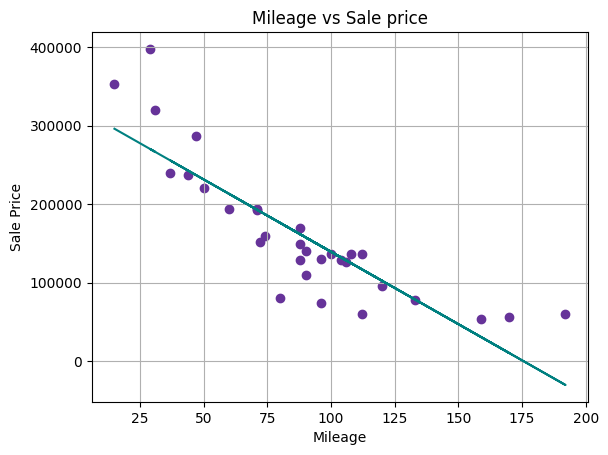

In [221]:
plt.scatter(mileage, y, color="rebeccapurple")

y_pred = b0_mileage + b1_mileage*mileage

plt.plot(mileage, y_pred,color="teal")

plt.xlabel("Mileage")
plt.ylabel("Sale Price")
plt.title("Mileage vs Sale price")


plt.grid()

plt.show()

## Categorical variables 

The dataset also includes two variables that behave as mon numerical, in the data set the variable names "Average Condition", "Excelent Condition" and "1 owner" are represented with 1 and 0, as binary language, a 1 represents a TRUE and a 0 represents a FALSE
<br>

The following relations wont be linear since their values are discrete data, non numerical, but for the sake of finding the correlation and determination coeficients the data will be treated as such. 
<br>

For future reference, discrete data doesnt really fit a linear regression model since these are built for processing numerical data, models that would work are either logistical regressions or a form of a random tree. 

In [222]:
dataframe_full = data

In [243]:
data =data.iloc[1:]


In [224]:
dataframe_full = data 

In [225]:
data=data.drop(columns=["Age","Mileage"])

In [244]:
data

,Sale price,Average condition,Excelent condition,One owner
1,60000,1,0,1
2,54000,0,0,1
3,59900,0,0,1
4,110000,1,0,0
5,79760,0,0,1
6,78000,0,0,1
7,56000,0,0,1
8,136000,0,1,0
9,125900,1,0,0
10,74000,0,0,1


In [227]:
new_names = ["Sale price", "Average condition", "Excelent condition", "One owner"]

In [228]:
data.columns = new_names

In [229]:
data

,Sale price,Average condition,Excelent condition,One owner
0,(pesos),Promedio,Excellent,One owner
1,60000,1,0,1
2,54000,0,0,1
3,59900,0,0,1
4,110000,1,0,0
5,79760,0,0,1
6,78000,0,0,1
7,56000,0,0,1
8,136000,0,1,0
9,125900,1,0,0


In [245]:
y = data["Sale price"]
y = y.astype(int) #out variable 

avg_cond= data["Average condition"]
avg_cond = avg_cond.astype(int)

excellent_cond = data["Excelent condition"]
excellent_cond = excellent_cond.astype(int)

one_owner = data["One owner"]
one_owner = one_owner.astype(int)

## Average condition vs Sale Price 

Text(0.5, 1.0, 'Average condition vs Sale price')

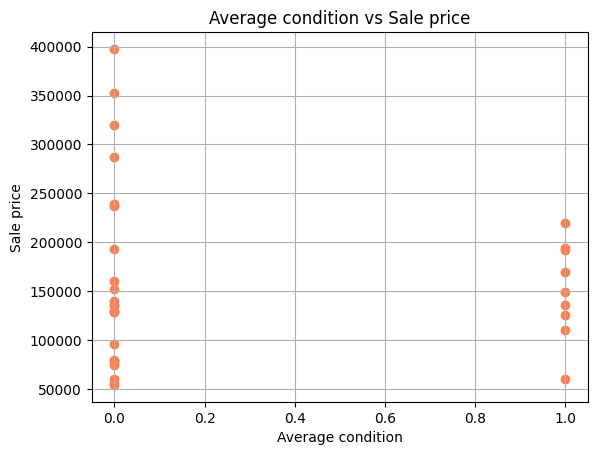

In [ ]:
plt.scatter(avg_cond, y, color="coral")
plt.grid()
plt.xlabel("Average condition")
plt.ylabel("Sale price")
plt.title("Average condition vs Sale price")

From the graph we cant really tell much, only that it seems that cars in average conditon dont really sell that expensive. <br>

And that the lower priced cars usually have a 0, which could mean that theyre poor quality cars, therefore their sale price is lower, but we need to check the "Excelent Condition" to check whether thats actually true or not.

In [ ]:
b1_avg_cond,b0_avg_cond,r_avg_cond= getLinearRegression(avg_cond,y)

print ("Slope:", b1_avg_cond)
print ("Intercept", b0_avg_cond)
print ("Pearson coefficient: ", r_avg_cond)


#checking w built in functions
model = LinearRegression()
X_avg_cond = avg_cond.values.reshape(-1,1)
model.fit(X_avg_cond, y)

print("Slope: ", model.coef_)
print("Intercept: ", model.intercept_)
print("Pearson coeficient: ", avg_cond.corr(y))

Slope: -14563.939393939394
Intercept 165297.27272727274
Pearson coefficient:  -0.07670774165498229
Slope:  [-14563.93939394]
Intercept:  165297.27272727274
Pearson coeficient:  -0.0767077416549823


The correlation coeficient its way too low to matter in our multiple linear regression model, we can say that a car being in average condition doesnt really either boost up or lower the sale price

In [ ]:
R_squared_avgcond= residualFunctions(avg_cond,y,b1_avg_cond,b0_avg_cond)
print("R-squared: ", R_squared_avgcond)


R-squared:  0.0058840776298074715


In [ ]:
model = LinearRegression()
model.fit(X_avg_cond, y)
model.score(X_avg_cond,y)

0.0058840776298074715

And by calculating R^2 we can safely say that the variable "Average Condition" doesnt really help explaining the output variable "Sale Price" 

## Excellent Condition vs Sale Price

Text(0.5, 1.0, 'Excellent condition vs Sale price')

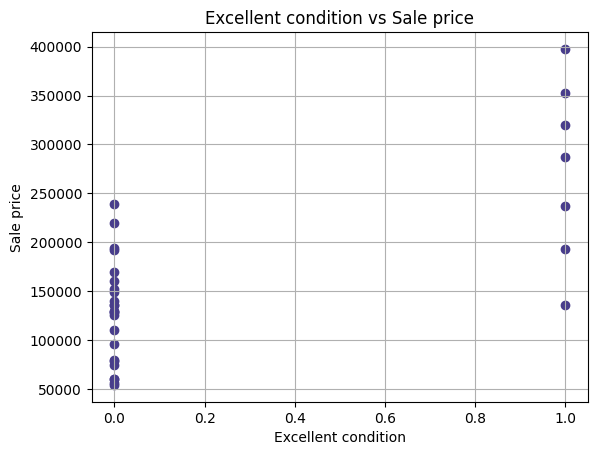

In [ ]:
plt.scatter(excellent_cond, y, color="darkslateblue")
plt.grid()
plt.xlabel("Excellent condition")
plt.ylabel("Sale price")
plt.title("Excellent condition vs Sale price")

From this graph we can infere that if a cars quality is excelent it will sell at a higher sale point. 

But we need to check r and R^2 to actually know how much of the "Excelent condition" variable is actually correlated w the output variable.

In [ ]:
b1_excellent_cond,b0_excellent_cond,r_excellent_cond= getLinearRegression(excellent_cond,y)
print ("Slope:", b1_excellent_cond)
print ("Intercept", b0_excellent_cond)
print ("Pearson coefficient: ", r_excellent_cond)

#checking w built in functions
model = LinearRegression()
X_excellent_cond = excellent_cond.values.reshape(-1,1)
model.fit(X_excellent_cond, y)
print("Slope: ", model.coef_)
print("Intercept: ", model.intercept_)
print("Pearson coeficient: ", excellent_cond.corr(y))

Slope: 147024.2857142857
Intercept 127870.0
Pearson coefficient:  0.7132987415290926
Slope:  [147024.28571429]
Intercept:  127870.0
Pearson coeficient:  0.7132987415290927


Analyzing the Pearson coefficient we can say that the sale price is positively correlated in a moderate strength. 

In [ ]:
R_squared_excellent_cond= residualFunctions(excellent_cond,y,b1_excellent_cond,b0_excellent_cond)
print("R-squared: ", R_squared_excellent_cond)

R-squared:  0.5087950946669872


In [ ]:
model = LinearRegression()
model.fit(X_excellent_cond, y)
model.score(X_excellent_cond,y)

0.5087950946669875

This tells us that the Excellent condition variable explains around 50% of the output of our model. 

## One owner vs Sale Price

This variable was interpreted as if the owner has had one previous owner.

Text(0.5, 1.0, 'One owner vs Sale price')

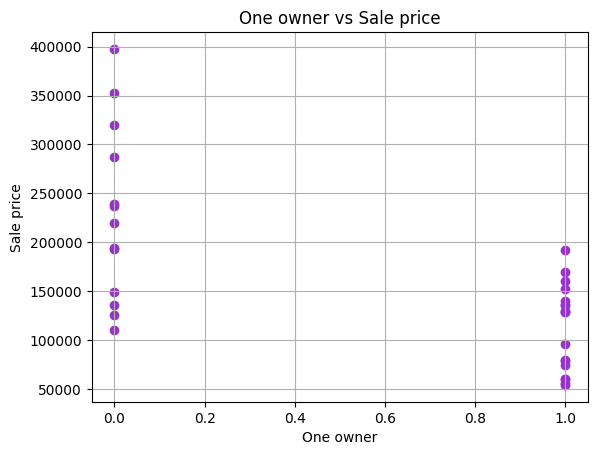

In [ ]:
plt.scatter(one_owner, y, color="darkorchid")
plt.grid()
plt.xlabel("One owner")
plt.ylabel("Sale price")
plt.title("One owner vs Sale price")

Based solely on the graph we could say that the cars that have had an owner in the past are cheaper than the ones that have not, although we need to calculate the coefficients of determination and Pearsons coefficients to say whether thats actually true or not. 

In [ ]:
b1_one_owner,b0_one_owner,r_one_owner= getLinearRegression(one_owner,y)
print ("Slope:", b1_one_owner)
print ("Intercept", b0_one_owner)
print ("Pearson coefficient: ", r_one_owner)    

#checking w built in functions
model = LinearRegression()
X_one_owner = one_owner.values.reshape(-1,1)
model.fit(X_one_owner, y)
print("Slope: ", model.coef_)
print("Intercept: ", model.intercept_)
print("Pearson coeficient: ", one_owner.corr(y))

Slope: -115052.735042735
Intercept 227873.84615384613
Pearson coefficient:  -0.6587681816714004
Slope:  [-115052.73504274]
Intercept:  227873.84615384616
Pearson coeficient:  -0.6587681816714005


Based on the Pearson coefficient we can say that the variables One owner and Sale Price are negatively correlated with moderate strength. 

In [ ]:
R_squared_one_owner= residualFunctions(one_owner,y,b1_one_owner,b0_one_owner)
print("R-squared: ", R_squared_one_owner)

R-squared:  0.43397551718264327


In [ ]:
model = LinearRegression()
model.fit(X_one_owner, y)
model.score(X_one_owner,y)

0.4339755171826434

With this Determination coefficient we can safely say that the variable "One owner" doesnt really explain with a high strength how the output variable behaves. 

## Correlation matrix 
A visual aid to see how these several coefficients actually fit together is through the following graph. 


In [234]:
data_full = pd.read_excel("/Users/tam_pr/Desktop/stats/stats/database/dataframe.xlsx") 



In [235]:
data_full

,Sale price,Age,Mileage,Condition,Unnamed: 4,Unnamed: 5
0,(pesos),(years),(miles),Promedio,Excellent,One owner
1,60000,9,112,1,0,1
2,54000,9,159,0,0,1
3,59900,8,192,0,0,1
4,110000,7,90,1,0,0
5,79760,7,80,0,0,1
6,78000,7,133,0,0,1
7,56000,7,170,0,0,1
8,136000,6,112,0,1,0
9,125900,6,106,1,0,0


In [236]:
data_full = data_full  .drop(0)

data_full.columns = [
    "Sale price",
    "Age",
    "Mileage",
    "Average Condition",
    "Excellent condition",
    "One owner"
]

data_full = data_full.astype(int)

print(data_full.head())

   Sale price  Age  Mileage  Average Condition  Excellent condition  One owner
1       60000    9      112                  1                    0          1
2       54000    9      159                  0                    0          1
3       59900    8      192                  0                    0          1
4      110000    7       90                  1                    0          0
5       79760    7       80                  0                    0          1


In [237]:
data_full

,Sale price,Age,Mileage,Average Condition,Excellent condition,One owner
1,60000,9,112,1,0,1
2,54000,9,159,0,0,1
3,59900,8,192,0,0,1
4,110000,7,90,1,0,0
5,79760,7,80,0,0,1
6,78000,7,133,0,0,1
7,56000,7,170,0,0,1
8,136000,6,112,0,1,0
9,125900,6,106,1,0,0
10,74000,6,96,0,0,1


In [ ]:
corr_matrix = data_full.corr()

print(corr_matrix)

                     Sale price       Age   Mileage  Average Condition  \
Sale price             1.000000 -0.872438 -0.856593          -0.076708   
Age                   -0.872438  1.000000  0.844503           0.124575   
Mileage               -0.856593  0.844503  1.000000          -0.030993   
Average Condition     -0.076708  0.124575 -0.030993           1.000000   
Excellent condition    0.713299 -0.504309 -0.538164          -0.345425   
One owner             -0.658768  0.461581  0.598070          -0.176540   

                     Excellent condition  One owner  
Sale price                      0.713299  -0.658768  
Age                            -0.504309   0.461581  
Mileage                        -0.538164   0.598070  
Average Condition              -0.345425  -0.176540  
Excellent condition             1.000000  -0.635489  
One owner                      -0.635489   1.000000  


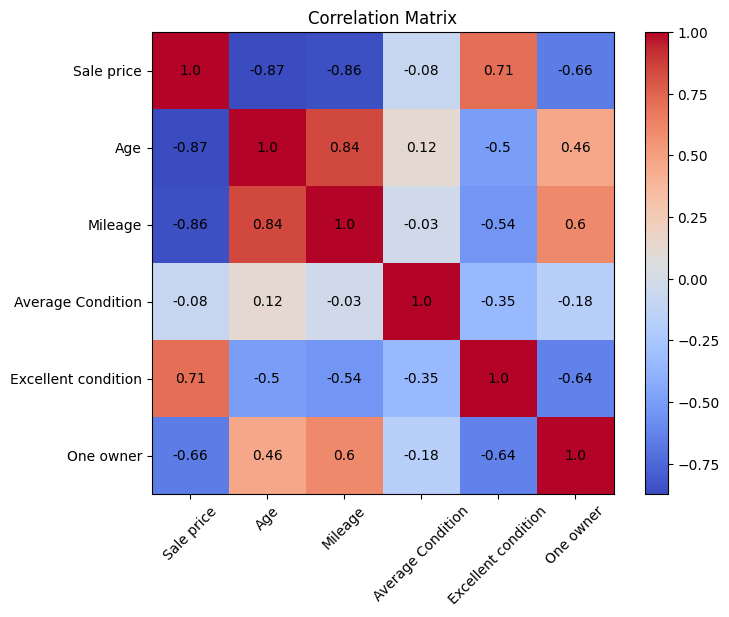

In [240]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, round(corr_matrix.iloc[i, j], 2),
                 ha='center', va='center', color='black')

plt.title("Correlation Matrix")

plt.show()

With this graph we can now clearly see how the variables that present a correlation to the output variable are as follows (from higher correlation strength to lower correlation strength): 
- Age: its a negative strong correlation, the older a car is the lower its price. 
- Mileage: its a negative strong correlation, if the car has a higher mileage, its price will be higher. 
- Excelent condition: positive moderate correlation: if the car is in excelent condition the price could be higher. 
- One owner: its a negative moderate correlation, if the car has had an owner before, it could be more cheap. 
- Average condition: this correlation coefficient its so low that it can be negligible, it doesnt really explain the output variable. 

## Multiple linear regression modeling 